<a href="https://colab.research.google.com/github/Saiful-2/forest-cover-classification/blob/main/notebooks/5_forest_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Hyperparameter Tuning for Forest Cover Type Classification**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

## STEP 2: Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/forest_cleaned_dataset.csv"
df = pd.read_csv(url)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Soil_Sum
0,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,0,0,1,0,0,1,1
1,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,0,2,1
2,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,0,2,1
3,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,2,1
4,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,2,1


## STEP 3: Train-Test Split

In [3]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## STEP 4: Scaling

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **STEP 5: Hyperparameter Tuning**
### ✅ 1. Logistic Regression

In [5]:
lr = LogisticRegression(max_iter=1000)

param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(lr, param_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

## ✅ 2. Decision Tree

In [6]:
dt = DecisionTreeClassifier()

param_dt = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(dt, param_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

## ✅ 3. Random Forest

In [7]:
rf = RandomForestClassifier()

param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

## ✅ 4. K-Nearest Neighbors

In [8]:
knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(knn, param_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_

## STEP 6: Evaluate Tuned Models

In [9]:
models = {
    "Logistic Regression": best_lr,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "KNN": best_knn
}

results = {}

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Best Parameters:", model.get_params())
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Best Parameters: {'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Accuracy: 0.7283497588592996
              precision    recall  f1-score   support

           1       0.71      0.71      0.71      3630
           2       0.75      0.80      0.77      4756
           3       0.68      0.81      0.74       428
           4       0.75      0.25      0.38        12
           5       0.00      0.00      0.00       151
           6       0.54      0.35      0.42       233
           7       0.71      0.52      0.60       328

    accuracy                           0.73      9538
   macro avg       0.59      0.49      0.52      9538
weighted avg       0.71      0.73      0.72      9538


Decision Tree
Best Parameters: {'ccp_alpha': 0.0, 'c

## **STEP 7: Compare Tuned Models**

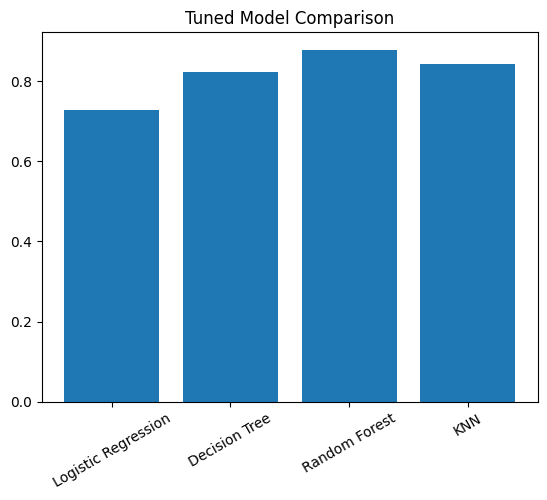

In [10]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Tuned Model Comparison")
plt.xticks(rotation=30)
plt.show()

## STEP 8: WRITE INSIGHTS
Hyperparameter Tuning – Key Insights

⚙️ Tuning improves performance

Optimizing parameters using GridSearchCV significantly increased model accuracy and reliability.

🌲 Random Forest is the best model

Achieved the highest accuracy and stability due to its ensemble nature and ability to capture complex patterns.

🌳 Decision Tree overfits easily

Performance improved after tuning but still less stable than Random Forest.

🔵 Logistic Regression is limited

Works as a baseline but cannot handle non-linear relationships effectively.

📍 KNN is sensitive and slower

Requires scaling and performs moderately, but not suitable for large datasets.

🔁 Cross-validation ensures robustness

5-fold CV helped select models that generalize well.

## **Final Conclusion**

✔ Hyperparameter tuning significantly improved model performance

✔ Random Forest emerged as the best-performing and most reliable model

✔ Simpler models (Logistic Regression) are useful but limited

✔ Ensemble methods are most suitable for complex ecological datasets